In [ ]:
%load_ext autoreload
%autoreload 2

### Import and run model

In [ ]:
# Forward pass with an untrained model.
from cs336_basics.model import TransformerLM
import torch

# device=torch.device("cuda")
device = torch.device("mps")
model = TransformerLM(
  vocab_size=10000,
  context_length=256,
  num_layers=8,
  d_model=768,
  num_heads=16,
  d_ff=1344,
  rope_theta=10000.0,
  device=device,
  dtype=torch.float32,
)

input = torch.randint(0, 10000, (1, 256), device=device)
output = model(input)
print(output.shape)

In [ ]:
# Generate text using a trained model.
from cs336_basics.generation import generate_text
from cs336_basics.tokenizer import BPETokenizer
from cs336_basics.model import TransformerLM
from cs336_basics.io import ROOT_PATH, load_checkpoint

tok = BPETokenizer.load(ROOT_PATH / "tokenizer/tinystories_train_10000.pt")

model, _, _ = load_checkpoint(
  ROOT_PATH / "model/TinyStories/volcanic-dream-4/checkpoint_39999.pt",
  model_class=TransformerLM,
)
text = generate_text(
  model=model,
  tokenizer=tok,
  input_text= "Costanza",
  max_new_tokens=100,
  temperature=1.0,
  top_p=0.0,
)
print(model._init_args)
text

### Models to benchmark

In [ ]:
from benchmark import MODELS, instantiate_model, model_size_mb

for name, model_config in MODELS.items():
  model = instantiate_model(model_config, 256)
  total_size_mb = model_size_mb(model)
  print(f"{name} model size: {total_size_mb:.2f} MB")

# small model size: 491.42 MB
# medium model size: 1615.82 MB
# large model size: 3700.26 MB
# xl model size: 7625.66 MB
# 2.7B model size: 12998.45 MB

### Basic Benchmark: Timeit

In [ ]:
%%bash
cd ..
uv run modal run cs336_systems/benchmark.py \
    --model-name="large" \
    --warmup-steps=5 \
    --no-synchronize \
    --no-measure-also-backward

uv run modal run cs336_systems/benchmark.py \
    --model-name="large" \
    --warmup-steps=5 \
    --synchronize \
    --no-measure-also-backward

uv run modal run cs336_systems/benchmark.py \
    --model-name="large" \
    --warmup-steps=5 \
    --synchronize \
    --measure-also-backward

In [ ]:
# Here are all the results for all the models.

# warmup_steps = 0. Notice the high std.
# --- small model (491.42 MB) ---
# without_sync_without_backward: 0.0892s ± 0.1655s
# with_sync_without_backward: 0.0303s ± 0.0024s
# with_sync_with_backward: 0.1095s ± 0.1056s
# --- medium model (1615.82 MB) ---
# without_sync_without_backward: 0.0818s ± 0.0434s
# with_sync_without_backward: 0.0659s ± 0.0001s
# with_sync_with_backward: 0.1975s ± 0.0004s
# --- large model (3700.26 MB) ---
# without_sync_without_backward: 0.1123s ± 0.0449s
# with_sync_without_backward: 0.1399s ± 0.0002s
# with_sync_with_backward: 0.4234s ± 0.0001s
# --- xl model (7625.66 MB) ---
# without_sync_without_backward: 0.2115s ± 0.1135s
# with_sync_without_backward: 0.2845s ± 0.0001s
# with_sync_with_backward: 0.8637s ± 0.0622s
# --- 2.7B model (12998.45 MB) ---
# without_sync_without_backward: 0.1527s ± 0.0012s
# with_sync_without_backward: 0.4181s ± 0.0001s
# with_sync_with_backward: 1.2662s ± 0.0234s

# warmup_steps = 5. Much lower std than before.
# --- small model (491.42 MB) ---
# without_sync_without_backward: 0.0312s ± 0.0002s
# with_sync_without_backward: 0.0340s ± 0.0032s
# with_sync_with_backward: 0.0767s ± 0.0008s
# --- medium model (1615.82 MB) ---
# without_sync_without_backward: 0.0633s ± 0.0013s
# with_sync_without_backward: 0.0670s ± 0.0014s
# with_sync_with_backward: 0.1997s ± 0.0014s
# --- large model (3700.26 MB) ---
# without_sync_without_backward: 0.0975s ± 0.0019s
# with_sync_without_backward: 0.1409s ± 0.0001s
# with_sync_with_backward: 0.4241s ± 0.0001s
# --- xl model (7625.66 MB) ---
# without_sync_without_backward: 0.1711s ± 0.0007s
# with_sync_without_backward: 0.2852s ± 0.0001s
# with_sync_with_backward: 0.8440s ± 0.0004s
# --- 2.7B model (12998.45 MB) ---
# without_sync_without_backward: 0.1548s ± 0.0024s
# with_sync_without_backward: 0.4184s ± 0.0001s
# with_sync_with_backward: 1.2589s ± 0.0012s

### PyTorch Profiler

In [ ]:
%%bash
# Generate the profile traces (in a way that is comparable to the timeit
# approach, i.e. with synchronization and without measuring the optimizer step).
cd ..
export TERM=dumb # Tell Modal this is not an interactive terminal.
uv run modal run scripts/profile_llm.py \
  --model-name="small" \
  --warmup-steps=3 \
  --active-steps=10 \
  --synchronize \
  --no-measure-optimizer

uv run modal run scripts/profile_llm.py \
  --model-name="medium" \
  --warmup-steps=3 \
  --active-steps=10 \
  --synchronize \
  --no-measure-optimizer

uv run modal run scripts/profile_llm.py \
  --model-name="large" \
  --warmup-steps=3 \
  --active-steps=10 \
  --synchronize \
  --no-measure-optimizer

uv run modal run scripts/profile_llm.py \
  --model-name="xl" \
  --warmup-steps=3 \
  --active-steps=10 \
  --synchronize \
  --no-measure-optimizer

uv run modal run scripts/profile_llm.py \
  --model-name="2.7B" \
  --warmup-steps=3 \
  --active-steps=10 \
  --synchronize \
  --no-measure-optimizer

In [ ]:
%%bash
# Download the profile traces from Modal to the local machine.
export TERM=dumb # Tell Modal this is not an interactive terminal.

uv run modal volume get cs336-systems-volume \
  small/20260422_205254/modal_2.1776891179763586779.pt.trace.json \
  ~/Downloads/traces/small.trace.json --force

uv run modal volume get cs336-systems-volume \
  medium/20260422_205322/modal_2.1776891211327914121.pt.trace.json \
  ~/Downloads/traces/medium.trace.json --force

uv run modal volume get cs336-systems-volume \
  large/20260422_205401/modal_2.1776891254347928161.pt.trace.json \
  ~/Downloads/traces/large.trace.json --force

uv run modal volume get cs336-systems-volume \
  xl/20260422_205448/modal_2.1776891308911727031.pt.trace.json\
  ~/Downloads/traces/xl.trace.json --force

uv run modal volume get cs336-systems-volume \
  2.7B/20260422_205600/modal_2.1776891393470086178.pt.trace.json \
  ~/Downloads/traces/2.7B.trace.json --force

### Timeit vs Profiling Summary

In [ ]:
import pandas as pd

cols = ["model_name", "measurement", "time"]
df = pd.DataFrame(columns=cols)

# Timeit results. 
df.loc[len(df)] = ["small", "timeit", "0.1095s ± 0.1056s"]
df.loc[len(df)] = ["medium", "timeit", "0.1997s ± 0.0014s"]
df.loc[len(df)] = ["large", "timeit", "0.4241s ± 0.0001s"]
df.loc[len(df)] = ["xl", "timeit", "0.8440s ± 0.0004s"]
df.loc[len(df)] = ["2.7B", "timeit", "1.2589s ± 0.0012s"]

# Profiler results. Without std (quite tedious to compute from the traces).
# Running the profiler introduces a lot of overhead.
df.loc[len(df)] = ["small", "profiler", "0.2794s"]
df.loc[len(df)] = ["medium", "profiler", "0.6005s"]
df.loc[len(df)] = ["large", "profiler", "1.058s"]
df.loc[len(df)] = ["xl", "profiler", "2.028s"]
df.loc[len(df)] = ["2.7B", "profiler", "2.827s"]

df

### Mixed precision

First, let's see the effect of having an accumulator (similarly to how gradients
would be accumulated) in float16.

In [ ]:
import torch

# Each one of these has an error (mathematically, we should get 10.0). 0.01
# cannot be exactly represented in binary, so we get a small error at each
# addition, and the error accumulates over the 1000 iterations.

# Accumulator in high precision.
# Sum values in high precision.
s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
  s += torch.tensor(0.01,dtype=torch.float32)
print(s)

# Accumulator in low precision.
# Sum values in low precision.
s = torch.tensor(0,dtype=torch.float16)
for i in range(1000):
  s += torch.tensor(0.01,dtype=torch.float16)
print(s)

# Accumulator in high precision.
# Sum values in low precision. However, the actual addition happens at 32-bit
# precision, which we explicitly do below and get to the same result.
s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
  s += torch.tensor(0.01,dtype=torch.float16)
print(s)

s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
  x = torch.tensor(0.01,dtype=torch.float16)
  s += x.type(torch.float32)
print(s)

Example on a dummy model in mixed precision.

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
uv run modal run scripts/profile_mixed_precision_example.py

In [ ]:
%%bash
# Download the profile traces from Modal to the local machine.
export TERM=dumb # Tell Modal this is not an interactive terminal.
uv run modal volume get cs336-systems-volume \
  mixed_precision_example_profiles/20260425_221245/modal_2.1777155168763138905.pt.trace.json \
  ~/Downloads/mixed_precision_example_profiles/trace.pt.trace.json --force

![Profiler Trace Screenshot](../assets/mixed_precision_example.png)

Benchmark again all the models with both half and full precision.

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
uv run modal run scripts/benchmark.py \
    --model-names="small,medium,large,xl,2.7B"

# --- small model ---
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=None                 :  0.0655s ± 0.0002s
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=torch.bfloat16       :  0.0475s ± 0.0009s

# --- medium model ---
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=None                 :  0.1993s ± 0.0002s
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=torch.bfloat16       :  0.1148s ± 0.0011s

# --- large model ---
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=None                 :  0.4298s ± 0.0001s
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=torch.bfloat16       :  0.1342s ± 0.0014s

# --- xl model ---
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=None                 :  0.9080s ± 0.0016s
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=torch.bfloat16       :  0.2484s ± 0.0006s

# --- 2.7B model ---
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=None                 :  1.3061s ± 0.0007s
# context_length=256  | backward=True  | sync=True  | warmup=5  | mixed_precision=torch.bfloat16       :  0.2670s ± 0.0004s

### Memory Profiler

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
# This script is modified in-place to generate different memory profiles.
uv run modal run scripts/benchmark.py \
    --model-names="xl" --profile-memory

Every line in the memory profile is a tensor allocation.

Here memory profiles of 3 train iterations (forward, backward, optimization)
*without warmup* for both full precision and half precision. Observations:
- During each forward pass, many activation tensors are allocated.
- During the first backward all gradient tensors are allocated.
- During each backward all activations are freed.
- During the first optimization, all momentum tensors (one for each tensor in
  the model) are allocated, and reused in next iterations.
- Half precision saved ~6GB: memory consumption during forward pass went from
  21GB to 27GB. This is because not all computations are done in half precision.

| **Full Precision (FP32)** | **Mixed Precision (BF16)** |
| :---: | :---: |
| ![FP32 Not Warmed Up](../assets/full_precision_not_warmed_up.png) | ![BF16 Not Warmed Up](../assets/half_precision_not_warmed_up.png) |

### Compile
torch.compile is a compiler stack that uses fusion as one of its primary
superpowers, but it does quite a bit more than just fusing kernels.

Let's check how many residuals are saved/loaded with a simple RMSNorm.

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
uv run modal run scripts/residuals_rms.py

# Without compiling:
# Saving residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
# Saving residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=<RsqrtBackward0 object at 0x2af0805fdb70>
# Saving residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=<RsqrtBackward0 object at 0x2af0805fdb70>
# Saving residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
# Saving residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=<MulBackward0 object at 0x2af0805fdb70>
# Saving residual: shape=torch.Size([2560]), dtype=torch.float32, grad_fn=None
# Loading residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=<MulBackward0 object at 0x2aefbcf48ac0>
# Loading residual: shape=torch.Size([2560]), dtype=torch.float32, grad_fn=None
# Loading residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=<RsqrtBackward0 object at 0x2aefbcf48ac0>
# Loading residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
# Loading residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=<RsqrtBackward0 object at 0x2aefbcf48ac0>
# Loading residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
# Compiling:
# Saving residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
# Saving residual: shape=torch.Size([2560]), dtype=torch.float32, grad_fn=None
# Saving residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=None
# Loading residual: shape=torch.Size([4, 512, 2560]), dtype=torch.float32, grad_fn=None
# Loading residual: shape=torch.Size([2560]), dtype=torch.float32, grad_fn=None
# Loading residual: shape=torch.Size([4, 512, 1]), dtype=torch.float32, grad_fn=None

Also try for a transformer block. Save almost 3GB, but still, 3.6 GB for a
transformer block would mean >100GB with aroung 30 transformer blocks.

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
uv run modal run scripts/residuals_transformer_block.py

# Without compiling:
# Total size of saved tensors in single TransformerBlock: 6442.62 MiB
# Compiling:
# Total size of saved tensors in single TransformerBlock: 3656.56 MiB

### Checkpointing
Checkpointing allows to tell torch to NOT save residuals for the computation
within a checkpoint. During the backward pass the forward pass will be computed
on the go.

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
uv run modal run scripts/checkpoint_transformer_block.py

# Without checkpoint:
# Total size of saved tensors in 4 TransformerBlock: 14626.25 MiB
# Peak memory: 15117.64 MiB
# With checkpoint:
# Total size of saved tensors in 4 TransformerBlock: 160.00 MiB
# Peak memory: 4307.96 MiB

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..

# uv run modal run scripts/checkpoint_llm.py \
#     --model-name="xl" \
#     --num-checkpoints=0

# Without compilation:
# OOO

# With compilation:
# OOO

uv run modal run scripts/checkpoint_llm.py \
    --model-name="xl" \
    --num-checkpoints=24

# Without compilation:
# Total size of saved tensor 2086.32 MiB
# Peak memory: 30202.62 MiB

# With compilation:
# Total size of saved tensor 1853.27 MiB
# Peak memory: 27561.51 MiB

uv run modal run scripts/checkpoint_llm.py \
    --model-name="xl" \
    --num-checkpoints=48

# Without compilation:
# Total size of saved tensor 3286.32 MiB  # 24 more checkpoints = need to save 24 more inputs (each 50 MB).
# Peak memory: 25649.65 MiB

# With compilation:
# Total size of saved tensor 3053.27 MiB  # 24 more checkpoints = need to save 24 more inputs (each 50 MB).
# Peak memory: 24067.37 MiB

### GPU Kernels

#### Benchmarch "naive" attention implementation

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..

uv run modal run scripts/benchmark_attention.py --compile

In [ ]:
import pandas as pd
df = pd.read_csv('../assets/benchmark_attention.csv', index_col=0)

df

#### Custom Triton kernel example

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
uv run modal run scripts/triton_example.py

#### Flash attention
Compare the flash attention implementation with the "naive" implementation.

In [ ]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
uv run modal run scripts/benchmark_flash_attention.py

In [ ]:
import pandas as pd
import seaborn as sns


# Load and clean: convert 'OOM' strings to NaN for plotting
df = pd.read_csv('../assets/benchmark_flash_attention.csv')
for col in ['forward_ms', 'backward_ms', 'tot_ms', 'peak_memory_mb']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

g1 = sns.relplot(
    data=df, x="seq_len", y="tot_ms", hue="implementation", 
    style="implementation", col="d_model", row="dtype",
    kind="line", marker="o", facet_kws={'sharey': False}
)
_ = g1.figure.suptitle("Total Runtime [ms]", y=1.05)

g2 = sns.relplot(
    data=df, x="seq_len", y="peak_memory_mb", hue="implementation",
    col="d_model", row="dtype", kind="line", marker="o"
)
_ = g2.figure.suptitle("Peak Memory Usage [MB]", y=1.05)

### Distributed Data Parallel Training

#### Benchmark Distributed Communication (Single Node)

Measure how much time it takes to tranfers tthe data transfer depending on
amount of data and/or the amount of processes:
- The time grows linearly with the amount of data.
- The time grows sub-linearly with the amount of processes.

In [61]:
%%bash
export TERM=dumb # Tell Modal this is not an interactive terminal.
cd ..
uv run modal run scripts/distributed_communication_single_node.py --gpu

✓ Initialized. View run at 
https://modal.com/apps/niccsacchi/main/ap-SLAzwrlOjIXE9g8FmqTNEk
✓ Created objects.
├── 🔨 Created mount 
│   /Users/niccolosacchi/assignment2-systems/scripts/distributed_communication_s
│   ingle_node.py
├── 🔨 Created mount PythonPackage:cs336_systems
├── 🔨 Created mount /Users/niccolosacchi/assignment2-systems/tests
├── 🔨 Created function run_0gpu.
├── 🔨 Created function run_2gpu.
├── 🔨 Created function run_4gpu.
└── 🔨 Created function run_6gpu.
{'mean_ms': np.float64(0.6671164999998425), 'std_ms': np.float64(0.0006594999995002127), 'world_size': 2, 'data_size_mb': 1.0}
{'mean_ms': np.float64(5.08701100000053), 'std_ms': np.float64(0.001304999999618417), 'world_size': 2, 'data_size_mb': 10.0}
{'mean_ms': np.float64(35.11175299999891), 'std_ms': np.float64(0.024796000001714447), 'world_size': 2, 'data_size_mb': 100.0}
{'mean_ms': np.float64(521.6389664999995), 'std_ms': np.float64(0.013735499997835632), 'world_size': 2, 'data_size_mb': 1000.0}
{'mean_ms': np

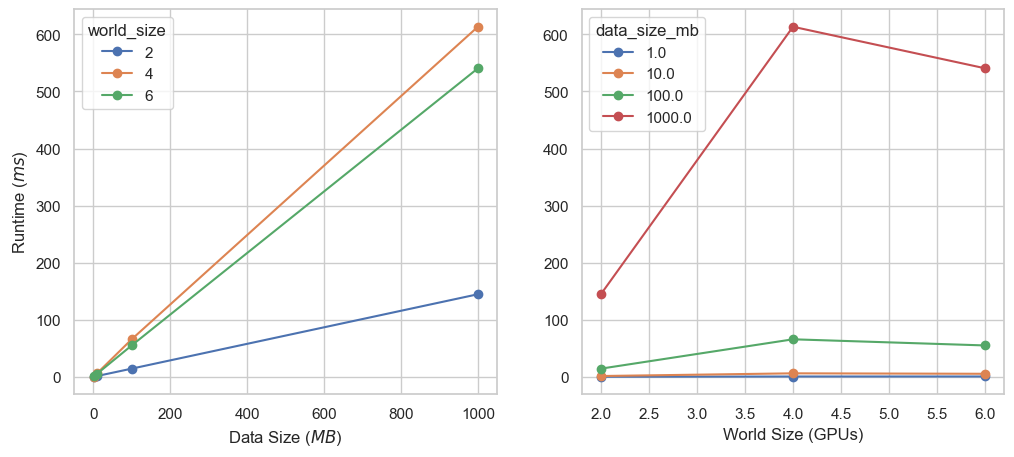

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df = pd.read_csv("../assets/distributed_communication_single_node.csv", index_col=0)

df.pivot(index="data_size_mb", columns="world_size", values="mean_ms").plot(ax=axes[0], marker="o")
axes[0].set_ylabel("Runtime ($ms$)")
axes[0].set_xlabel("Data Size ($MB$)")

df.pivot(index="world_size", columns="data_size_mb", values="mean_ms").plot(ax=axes[1], marker="o")
axes[1].set_xlabel("World Size (GPUs)")

plt.show()